<!-- GENERATED by scripts/build_problems.py from
     DA4CHE-admin/problems/Topic1.4-Numerical_Optimization/master.md
     Do not edit this file directly — your changes will be overwritten.
     Solutions and rubrics live in the private repo and must never appear here. -->

```{contents}
:local:
:depth: 2
```

# Problems: Numerical Optimization

:::{admonition} Get this problem set
:class: seealso

{download}`Download everything (Topic1.4-Numerical_Optimization_Problems.zip) <archives/Topic1.4-Numerical_Optimization_Problems.zip>` — the notebook and
`co2_isotherm_13x_298K.csv`, in a folder that is ready to run as-is.

The Download badge at the top of the page will also give you the notebook on its own.
On Vocareum everything is already set up for you.
:::

:::{admonition} Before you start
:class: tip

This problem set accompanies {doc}`Numerical Optimization </1-numerical_methods/Topic1.4-Numerical_Optimization>`. It is worth **100 points**:

- **Part A — Skill Checks (30 pts)** — short answers, auto-graded, resubmit as often as
  you like until they pass.
- **Part B — Visualization (35 pts)** — plots plus written interpretation, peer graded.
- **Part C — Open Ended (35 pts)** — one synthesis problem, peer graded.

The parts build on each other: Part A works out the syntax you need for Part B, and
Part B produces the evidence you argue from in Part C. Do them in order.
:::



## Setup

The chapter fit a sum of Gaussians to an infrared spectrum. Here the model is a
**Langmuir adsorption isotherm**, and the data is a measurement of how much CO₂ a
zeolite holds as the gas pressure rises.

**Zeolite 13X** is the benchmark sorbent for CO₂ capture: a crystalline aluminosilicate
whose pores hold CO₂ far more strongly than N₂, which is what makes post-combustion
separation possible at all. The isotherm below was measured at 298 K and digitized into
the NIST/ARPA-E Adsorption Database from Yang et al., *Adsorption* **26**, 1305 (2020),
[doi:10.1007/s10450-020-00296-3](https://doi.org/10.1007/s10450-020-00296-3).

The Langmuir model assumes a fixed number of identical adsorption sites, each either
empty or holding one molecule:

$$
q(P) \;=\; \frac{q_m\, b\, P}{1 + b\,P}
$$

Two parameters, both physically meaningful. $q_m$ is the **saturation loading** in mmol/g
— how much the material holds once every site is full — and $b$ is the **affinity
constant** in bar⁻¹, which sets how quickly it fills. At low pressure $bP \ll 1$ and the
isotherm is nearly a straight line of slope $q_m b$; at high pressure it flattens at
$q_m$. This is the whole problem set: two parameters that live on completely different
scales, in a model that is not linear in either of them.

This set needs `autograd`, exactly as the chapter does. Run this once if you do not have
it:

In [ ]:
!pip install autograd

In [1]:
%matplotlib inline
import autograd.numpy as np           # a drop-in replacement, as in the chapter
from autograd import grad, hessian
import pandas as pd
import matplotlib.pyplot as plt
try:
    plt.style.use('../settings/plot_style.mplstyle')   # available inside the book
except OSError:
    pass                                              # downloaded notebook: use defaults

df = pd.read_csv('data/co2_isotherm_13x_298K.csv')
P = df['pressure [bar]'].values
Q = df['loading [mmol/g]'].values
print(f"{len(P)} points;  P = {P.min():.1e} to {P.max():.4f} bar;  "
      f"q = {Q.min():.4f} to {Q.max():.3f} mmol/g")

35 points;  P = 2.0e-05 to 0.9629 bar;  q = 0.0373 to 5.196 mmol/g


The pressures span nearly five decades, so every plot of the isotherm itself wants a
**logarithmic pressure axis**. On a linear axis two thirds of the measurements pile up
against the left edge.

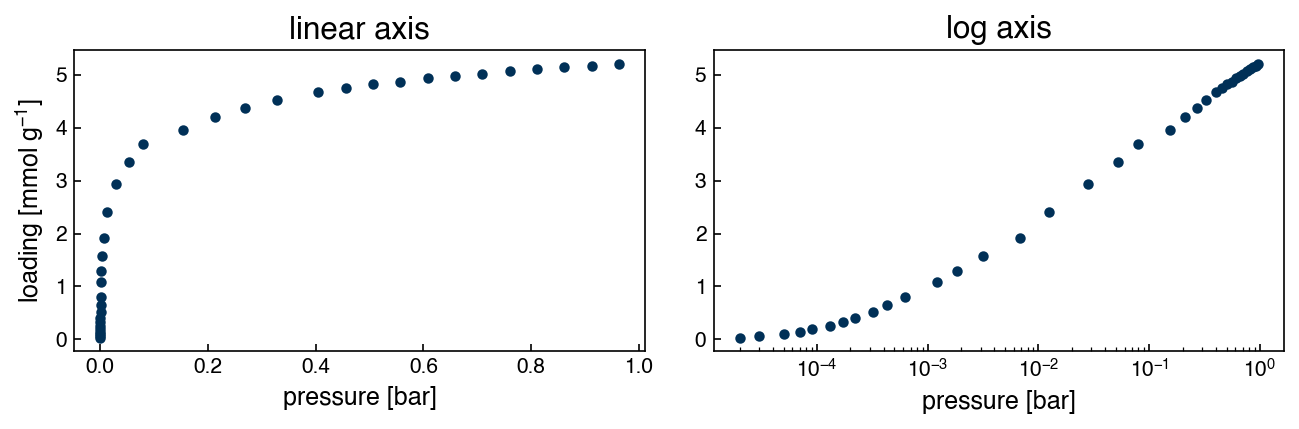

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.2))
ax1.plot(P, Q, 'o', ms=4)
ax1.set_xlabel('pressure [bar]')
ax1.set_ylabel('loading [mmol g$^{-1}$]')
ax1.set_title('linear axis')

ax2.semilogx(P, Q, 'o', ms=4)
ax2.set_xlabel('pressure [bar]')
ax2.set_title('log axis')
plt.tight_layout();

Run this once. It defines the `check` helper used after each Part A answer. It will
not run inside the book — use the downloaded notebook.

In [ ]:
# Run this once. It defines `check`, used after each Part A answer below.
import hashlib

_EXPECTED = {
    'q1': (4, ['169d073b8ac8', '071dfcbba161', 'fdbb2c44676d', '04ff40ff6ae9', 'f51cf1b3beb5', '409b57cd5c5d', '743e55710c19', '125ea834e92b', '9df62094f6be', 'a710098349c2', '53d876e4a777', '20fa38593026', '4377fb02a3f1']),
    'q2': (3, ['969327c99e19', 'a1e4593b21fd', 'd00367ce8982', 'c5f98ac682b0', 'bbe420df909d', 'ede4b6829e38', '74471c58c19d']),
    'q3': (4, ['8a8d1d835236', '08a9e2dfca87', '2468af0552a0', '2cb5ff75daf4', '20b29d7c2521', '3236770c0897', '98930a3d2c61', 'a55e4bef86ad', '50d16e3878a2', 'c71e5032ab39', 'c34755801579']),
}

def check(qid, value):
    """Compare an answer against a stored digest. Practice only -- nothing is recorded."""
    places, digests = _EXPECTED[qid]
    if value is Ellipsis:
        print(f"{qid}: not answered yet")
        return
    got = hashlib.sha256(f"{float(value):.{places}f}".encode()).hexdigest()[:12]
    print(f"{qid}: {'correct' if got in digests else 'not the expected value'}")

---

## Part A — Skill Checks (30 pts)

Three questions, 10 points each. Each asks you to assign a single number to a named
variable. Run the check cell after each one; there is no limit on attempts.

### A1. Get a starting guess for free (10 pts)

:::{exercise}
:label: pr-nm-lang-linearize

The Langmuir equation is not linear in $q_m$ or $b$, but it can be rearranged until it is
linear in something. Divide both sides into $P$:

$$
\frac{P}{q} \;=\; \frac{1}{q_m b} \;+\; \frac{P}{q_m}
$$

So plotting $P/q$ against $P$ should give a straight line whose **slope is $1/q_m$** and
whose **intercept is $1/(q_m b)$**. That is an ordinary linear least-squares problem of
exactly the kind {doc}`Linear Regression </1-numerical_methods/Topic1.3-Linear_Regression>`
solves.

Build the two-column design matrix $\bar{\bar{X}}$ — a column of ones for the intercept
and a column of $P$ for the slope — and solve the normal equations
$\bar{\bar{X}}^T\bar{\bar{X}}\vec{w} = \bar{\bar{X}}^T\vec{y}$ with `np.linalg.solve`,
where $\vec{y}$ is $P/q$. Use all 35 points.

Assign the saturation loading $q_m = 1/\text{slope}$, in mmol/g, to `q_m_linear`.
:::

In [ ]:
# YOUR CODE HERE
q_m_linear = ...

In [ ]:
check("q1", q_m_linear)

### A2. Write the objective and differentiate it (10 pts)

:::{exercise}
:label: pr-nm-lang-gradnorm

Now set up the real problem. Pack the parameters into a single vector
$\vec{\lambda} = [q_m,\, b]$ and write the **plain sum of squared errors**:

$$
g(\vec{\lambda}) \;=\; \sum_i \left( \frac{q_m b P_i}{1 + b P_i} - q_i \right)^2
$$

Note this is the plain sum — **do not** divide by the number of points, as the chapter's
`gaussian_loss` did. Write it as a function of one argument, as the chapter does, so
`autograd` can differentiate it, then get the gradient function with `grad`.

Every part of this problem set starts from the same round-number guess:

$$
\vec{\lambda}_0 = [\,5.0,\; 65.0\,]
$$

Assign the norm of the gradient at $\vec{\lambda}_0$, via `np.linalg.norm`, to
`grad_norm_init`.
:::

In [ ]:
# YOUR CODE HERE
grad_norm_init = ...

In [ ]:
check("q2", grad_norm_init)

### A3. Hand it to a real optimizer (10 pts)

:::{exercise}
:label: pr-nm-lang-bfgs

Pass the same objective and the same starting guess $\vec{\lambda}_0$ to
`scipy.optimize.minimize` with `method='BFGS'` and default settings, exactly as the
chapter does.

Assign the sum of squared errors **at the optimum** to `sse_bfgs`.
:::

In [ ]:
# YOUR CODE HERE
sse_bfgs = ...

In [ ]:
check("q3", sse_bfgs)

---

## Part B — Visualization (35 pts)

BFGS got there in a handful of iterations. Now do it yourself, with the chapter's own
gradient descent, and find out what that costs.

Everything in this part is a picture of the **same two-dimensional surface**: the SSE as a
function of $(q_m, b)$. Use this helper to draw it — it is provided so that everyone's
figures are comparable, and so the work goes into the optimization rather than into
matplotlib.

In [3]:
def sse_surface(qm_range=(3.0, 7.0), b_range=(20.0, 300.0), n=120):
    """SSE on a grid of (q_m, b). Returns meshgrids QM, B and the SSE values Z."""
    qm = np.linspace(qm_range[0], qm_range[1], n)
    b = np.logspace(np.log10(b_range[0]), np.log10(b_range[1]), n)
    QM, B = np.meshgrid(qm, b)
    pred = QM[:, :, None] * B[:, :, None] * P[None, None, :] \
        / (1 + B[:, :, None] * P[None, None, :])
    Z = np.sum((pred - Q[None, None, :]) ** 2, axis=2)
    return QM, B, Z


def plot_landscape(ax, qm_range=(3.0, 7.0), b_range=(20.0, 300.0),
                   logy=True, levels=None, n=120):
    """Contour the SSE surface onto `ax`. Returns the contour set."""
    QM, B, Z = sse_surface(qm_range, b_range, n)
    if levels is None:
        levels = np.logspace(np.log10(4.4), np.log10(200), 16)
    cs = ax.contour(QM, B, Z, levels=levels, colors='0.65', linewidths=0.6)
    if logy:
        ax.set_yscale('log')
    ax.set_xlabel('$q_m$ [mmol g$^{-1}$]')
    ax.set_ylabel('$b$ [bar$^{-1}$]')
    return cs

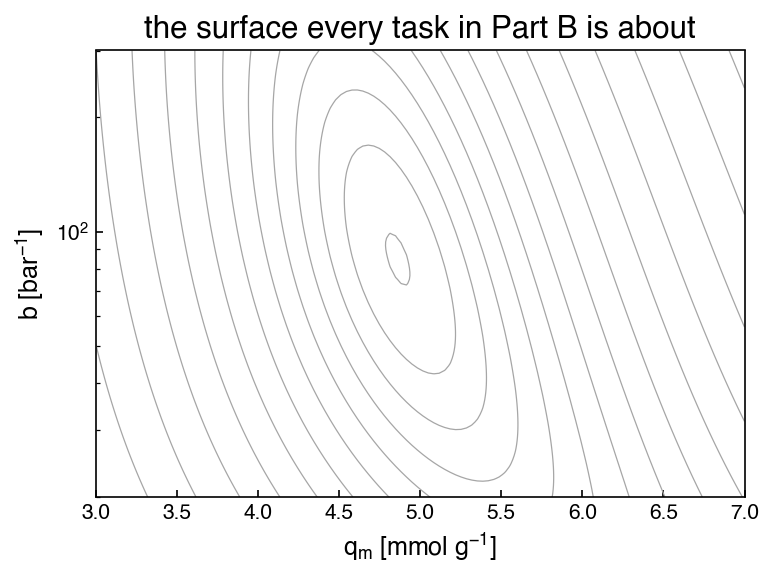

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 4.2))
plot_landscape(ax)
ax.set_title('the surface every task in Part B is about')
plt.tight_layout();

::::{exercise}
:label: pr-nm-lang-step-size

Write the chapter's fixed-step gradient descent: repeatedly replace
$\vec{\lambda} \leftarrow \vec{\lambda} - h\,\nabla g(\vec{\lambda})$ for a fixed
**1,000 iterations**, the same `N_iter` the chapter uses. Unlike the chapter's loop, keep
the whole history — every task below plots it.

**1. Where the descent actually goes.** Run it from $\vec{\lambda}_0 = [5.0,\, 65.0]$ at
$h = 10^{-5}$, $10^{-3}$ and $10^{-1}$. Plot all three **trajectories on the contour map**
with `plot_landscape`, marking the start and the A3 optimum. Beside the figure, give a
short table: final SSE, and the **fraction of the required change each parameter achieved**,

$$
\frac{\lambda_j^{\text{final}} - \lambda_j^{(0)}}{\lambda_j^{\text{opt}} - \lambda_j^{(0)}}
\times 100\%
$$

for $j = q_m$ and $j = b$, using your A3 optimum as $\lambda^{\text{opt}}$.

:::{admonition} Guard against overflow
:class: warning

At the largest step size the SSE overflows within a few iterations. Break out of the loop
when the SSE stops being finite or exceeds, say, $10^{12}$, and record the iteration at
which that happened — otherwise you will spend the rest of the run propagating `inf` and
`nan`, and nothing will plot.
:::

:::{note}
When plotting the trajectories, set the axis limits explicitly to the suggested
`plot_landscape` range (i.e., `qm_range=(3.0, 7.0)`) — otherwise the contour-map domain
will be dominated by the diverged direction.
:::

**2. Two views of the same failure.** A two-panel figure: SSE against iteration on a
**logarithmic $y$ axis** for all three step sizes, with a horizontal reference line at your
A3 optimum; and beside it $q_m$ and $b$ against iteration (two panels or twin axes), each
with a horizontal line at its optimal value. One of those parameter traces will be visibly
flat.

**3. Does the starting guess matter?** Re-run at $h = 10^{-5}$ and $10^{-3}$ from

- $[5.0,\; 0.65]$ — the affinity constant 100× too small, and
- $[500,\; 6500]$ — both parameters 100× too large,

and plot these trajectories on the contour map as well. You will need wider axis ranges to
see the second one; say what you chose. Report the final SSE each run reaches.

**4. The shape of the valley.** The surface has a direction that is steep and a direction
that is flat, and the ratio is what defeated task 1. Measure it. The matrix of second
derivatives — the **Hessian** — is available from `autograd` exactly as the gradient was:

```python
H = hessian(sse)(lam_opt)
```

Take its eigenvalues and eigenvectors with `np.linalg.eigh`. Each eigenvector points along
a principal direction of the surface, and moving a distance $1/\sqrt{\lambda_i}$ along it
raises the SSE by the same amount in every direction — so those distances measure how far
you can travel before the fit degrades.

Plot a **zoomed** contour map near the optimum on a **linear** $b$ axis (the Hessian is a
local statement, so zoom in until the contours look like ellipses), and draw both
eigenvector directions as arrows of length $1/\sqrt{\lambda_i}$ from the optimum.

Report the two arrow lengths and their ratio, then **in one or two sentences** say why no
single step size could have worked in task 1.

Label your axes with units.
::::

In [ ]:
# YOUR CODE HERE
fig, ax = plt.subplots()

---

## Part C — Open Ended (35 pts)

Part B measured the problem: the loss surface is a long narrow valley, and the ratio of its
two curvatures — the **condition number** of the Hessian, $\lambda_{\max}/\lambda_{\min}$ —
is what a single step size cannot cope with. You met condition numbers in
{doc}`Linear Algebra </1-numerical_methods/Topic1.2-Linear_Algebra>`, where a large one
meant a linear solve had lost its accuracy; here it has a shape.

There are two completely different things you can change about a fitting problem, and this
part is about telling them apart:

- the **parameterization** — the coordinates you search in, and
- the **model** and the **loss** — what you are fitting and what counts as a good fit.

One of them moves the answer. The other does not.

::::{exercise}
:label: pr-nm-lang-rescale

**1. Change the coordinates.** Your two fitted parameters differ by more than an order of
magnitude and both must stay positive, and both problems go away if you search in the
*logarithms* instead. Define $\vec{z} = [\ln q_m,\, \ln b]$, write an objective that takes
$\vec z$, exponentiates it, and returns the same SSE, then run **the same gradient descent,
at the same three step sizes, for the same 1,000 iterations** from
$\vec{z}_0 = \ln\vec{\lambda}_0$.

Report the same quantities as Part B task 1, remembering to exponentiate before quoting
$q_m$ and $b$, and report `np.linalg.cond(H)` for the Hessian in **both** parameterizations.
Plot the log-parameter trajectories on the contour map alongside the raw ones from Part B —
on the same $(q_m, b)$ axes, so the two are comparable.

**2. Change the model.** Langmuir assumes every adsorption site is identical, which for a
real zeolite is optimistic. Pick **at least one** other isotherm model, fit it to the same
data, and plot it against the Langmuir fit. Some standard choices, all fittable with what
you already have:

| model | $q(P)$ | parameters |
|---|---|---|
| Freundlich | $K P^{n}$ | $K, n$ |
| Sips | $q_m (bP)^{t} / \left[1 + (bP)^{t}\right]$ | $q_m, b, t$ |
| Tóth | $q_m b P / \left[1 + (bP)^{t}\right]^{1/t}$ | $q_m, b, t$ |
| dual-site Langmuir | $\dfrac{q_1 b_1 P}{1 + b_1 P} + \dfrac{q_2 b_2 P}{1 + b_2 P}$ | $q_1, b_1, q_2, b_2$ |

Fit in log parameters — you have just seen why. For each model you try, report the SSE and
`np.linalg.cond(H)` at its optimum, and say in one sentence what the extra freedom bought.

:::{note}
The Tóth model comes back in
{doc}`Nonlinear Parameter Estimation </1-numerical_methods/Topic1.5-Parameter_Estimation>`,
where the question becomes how *certain* its parameters are. You are welcome to use it here.
:::

**3. Change the loss.** Everything so far has minimized the plain sum of squared errors in
$q$. That is a choice. Compare **at least three** different loss functions on the same
model, on two axes — the quality of the fit they produce, and how numerically well behaved
they are. Required: the plain SSE in $q$; the SSE of the **log-transformed** residuals,

$$
g_{\log}(\vec\lambda) \;=\; \sum_i \left[\ln q(P_i;\vec\lambda) - \ln q_i\right]^2 ,
$$

and the loss for whichever model you chose in task 2. Others you may add: the mean squared
error, or an SSE with a soft penalty added as the chapter describes.

For each loss, report where it lands (the fitted parameters), the **plain** SSE evaluated at
that optimum so the comparison is on one scale, and `np.linalg.cond(H)`.

**4. Two numbers, then one or two sentences.** Report the condition-number improvement from
task 1, and the largest difference in fitted $q_m$ between any two of your task-3 losses.

Then, **in one or two sentences**: which of the three changes altered *where the optimum is*,
and which only altered *how hard it was to get there*?
::::

In [ ]:
# YOUR CODE HERE